In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel('/content/Efectividad conscol.xlsx')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (7643, 11)

Columns: ['Centro planificación', 'Cuenta contrato', 'Orden', 'Estatus de Usuario', 'Efectividad', 'Clase actividad PM', 'Fecha de Ejecución (Fin)', 'D_Prod._Serv', 'D_Mercado', 'D_Municipio', 'Nombre del técnico ODS']

Missing values:
 Centro planificación        0
Cuenta contrato             0
Orden                       0
Estatus de Usuario          0
Efectividad                 0
Clase actividad PM          0
Fecha de Ejecución (Fin)    0
D_Prod._Serv                0
D_Mercado                   4
D_Municipio                 0
Nombre del técnico ODS      0
dtype: int64


,Centro planificación,Cuenta contrato,Orden,Estatus de Usuario,Efectividad,Clase actividad PM,Fecha de Ejecución (Fin),D_Prod._Serv,D_Mercado,D_Municipio,Nombre del técnico ODS
0,1501,62315624,69115437,EJPG,Efectiva,K30,2025-12-01,Cotizacion cambio uso y/o aumento capaci,Comercial,BOGOTA,Bryam Caceres Garcia
1,1501,64279417,86013742,EJPG,Efectiva,L20,2025-12-01,Cotizacion traslado de acometida,Residencial Saturación,BOGOTA,Daniel Ortiz Barajas
2,1501,61561864,69115618,EJPG,Efectiva,K30,2025-12-01,Cotizacion cambio uso y/o aumento capaci,Comercial,BOGOTA,Filleral Castillo Muñoz
3,2401,60164280,78334104,EJEC,Efectiva,J12,2025-12-01,Cambio de uso de Pyme a residencial,Comercial,CHIA,Victor Delgado Espinosa
4,1501,61524933,69114443,EJPG PLAN,Efectiva,K10,2025-12-02,Visita integral,Residencial Saturación,BOGOTA,Anderson Prieto Sanchez


In [2]:
# Statistical summary
print(df.describe())

# Efectividad distribution
print("\nEfectividad:")
print(df['Efectividad'].value_counts())
print("\nEfectividad %:")
print(df['Efectividad'].value_counts(normalize=True).round(4) * 100)

# Centro planificacion
print("\nCentro planificacion:")
print(df['Centro planificación'].value_counts())

# Create numeric column: 1 = Efectiva, 0 = No Efectiva
df['Efectiva_num'] = (df['Efectividad'] == 'Efectiva').astype(int)
print("\nColumna Efectiva_num creada correctamente")

       Centro planificación  Cuenta contrato         Orden  \
count           7643.000000     7.643000e+03  7.643000e+03   
mean            1737.333900     6.172687e+07  7.961017e+07   
min             1501.000000     6.000003e+07  6.500533e+07   
25%             1501.000000     6.072483e+07  6.914056e+07   
50%             1501.000000     6.157654e+07  7.833683e+07   
75%             2401.000000     6.246447e+07  8.503328e+07   
max             2401.000000     6.451383e+07  9.707809e+07   
std              396.064795     1.217483e+06  9.307932e+06   

            Fecha de Ejecución (Fin)  
count                           7643  
mean   2026-01-11 12:45:52.636399360  
min              2025-12-01 00:00:00  
25%              2025-12-19 00:00:00  
50%              2026-01-13 00:00:00  
75%              2026-02-03 00:00:00  
max              2026-02-27 00:00:00  
std                              NaN  

Efectividad:
Efectividad
Efectiva       5056
No Efectiva    2587
Name: count, dtype: int6

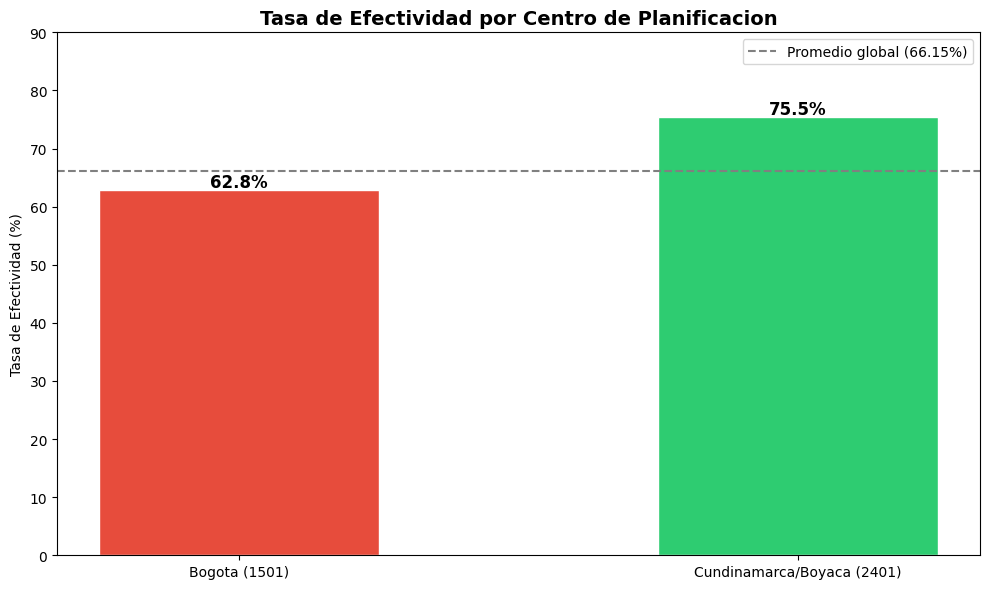

In [3]:
# Efectividad por centro de planificacion
efectividad_centro = df.groupby('Centro planificación')['Efectiva_num'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    ['Bogota (1501)', 'Cundinamarca/Boyaca (2401)'],
    efectividad_centro.values,
    color=['#E74C3C', '#2ECC71'],
    edgecolor='white',
    width=0.5
)

for bar, val in zip(bars, efectividad_centro.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.axhline(y=66.15, color='gray', linestyle='--', label='Promedio global (66.15%)')
ax.set_title('Tasa de Efectividad por Centro de Planificacion', fontsize=14, fontweight='bold')
ax.set_ylabel('Tasa de Efectividad (%)')
ax.set_ylim(0, 90)
ax.legend()
plt.tight_layout()
plt.savefig('efectividad_centro.png', dpi=150)
plt.show()

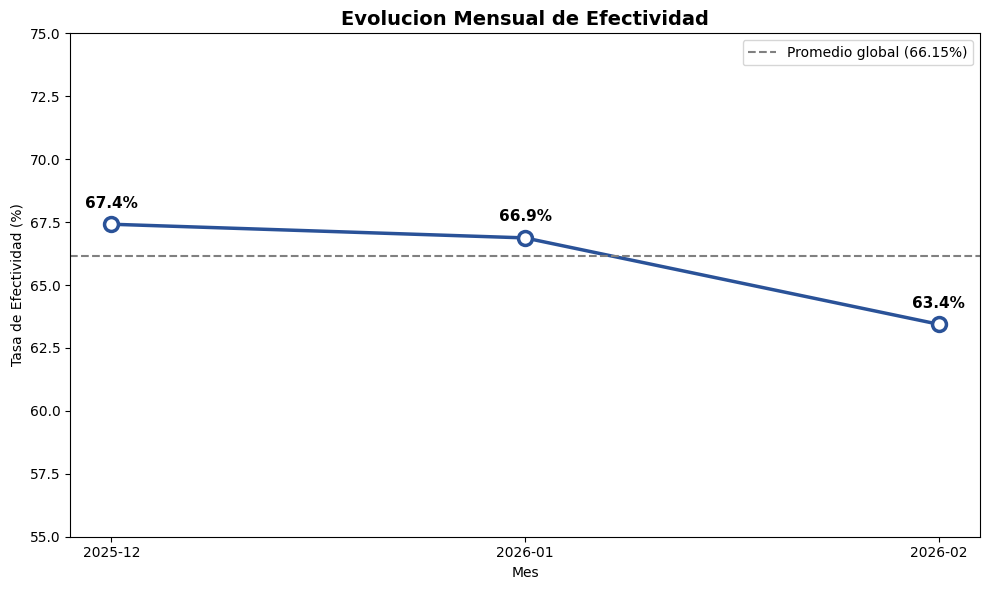

In [4]:
# Efectividad mensual
df['Mes'] = df['Fecha de Ejecución (Fin)'].dt.to_period('M').astype(str)

efectividad_mes = df.groupby('Mes')['Efectiva_num'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(efectividad_mes.index, efectividad_mes.values,
        marker='o', linewidth=2.5, markersize=10,
        color='#2A5298', markerfacecolor='white', markeredgewidth=2.5)

for x, y in zip(efectividad_mes.index, efectividad_mes.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 12), ha='center', fontweight='bold', fontsize=11)

ax.axhline(y=66.15, color='gray', linestyle='--', label='Promedio global (66.15%)')
ax.set_title('Evolucion Mensual de Efectividad', fontsize=14, fontweight='bold')
ax.set_ylabel('Tasa de Efectividad (%)')
ax.set_xlabel('Mes')
ax.set_ylim(55, 75)
ax.legend()
plt.tight_layout()
plt.savefig('efectividad_mensual.png', dpi=150)
plt.show()

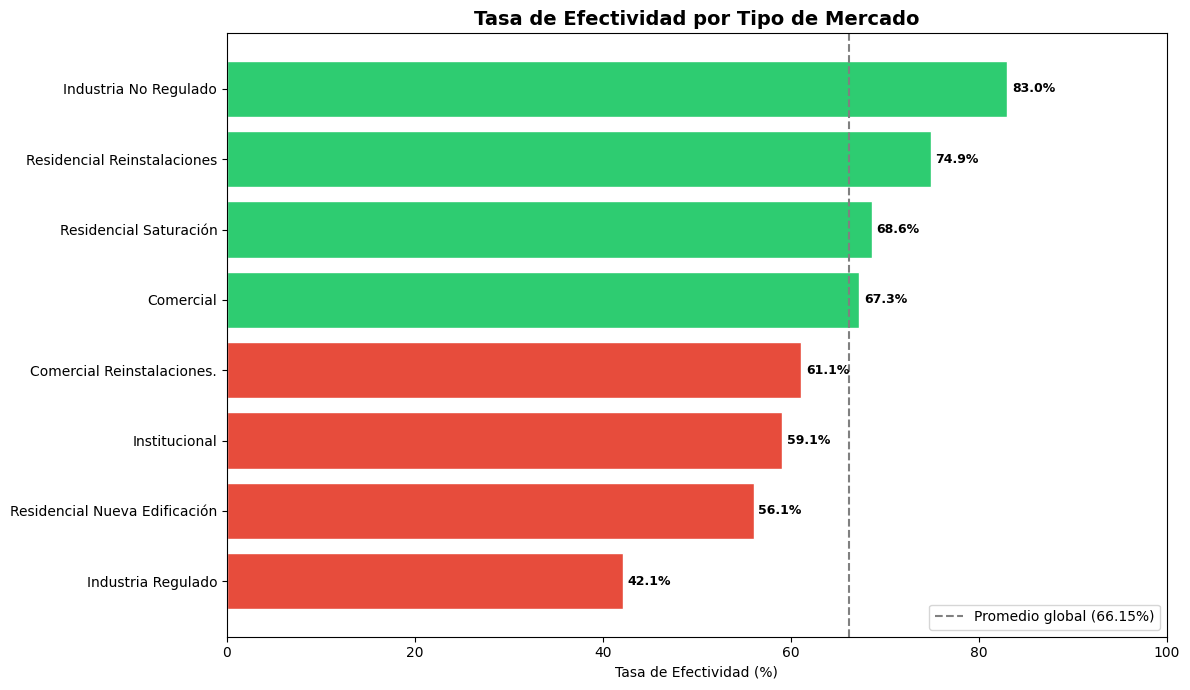

In [5]:
# Efectividad por mercado
efectividad_mercado = df.groupby('D_Mercado')['Efectiva_num'].agg(['mean', 'count'])
efectividad_mercado['mean'] = efectividad_mercado['mean'] * 100
efectividad_mercado = efectividad_mercado[efectividad_mercado['count'] > 10].sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

colors_list = ['#E74C3C' if v < 66.15 else '#2ECC71' for v in efectividad_mercado['mean']]

bars = ax.barh(efectividad_mercado.index, efectividad_mercado['mean'],
               color=colors_list, edgecolor='white')

for bar, val in zip(bars, efectividad_mercado['mean']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=9)

ax.axvline(x=66.15, color='gray', linestyle='--', label='Promedio global (66.15%)')
ax.set_title('Tasa de Efectividad por Tipo de Mercado', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Efectividad (%)')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('efectividad_mercado.png', dpi=150)
plt.show()

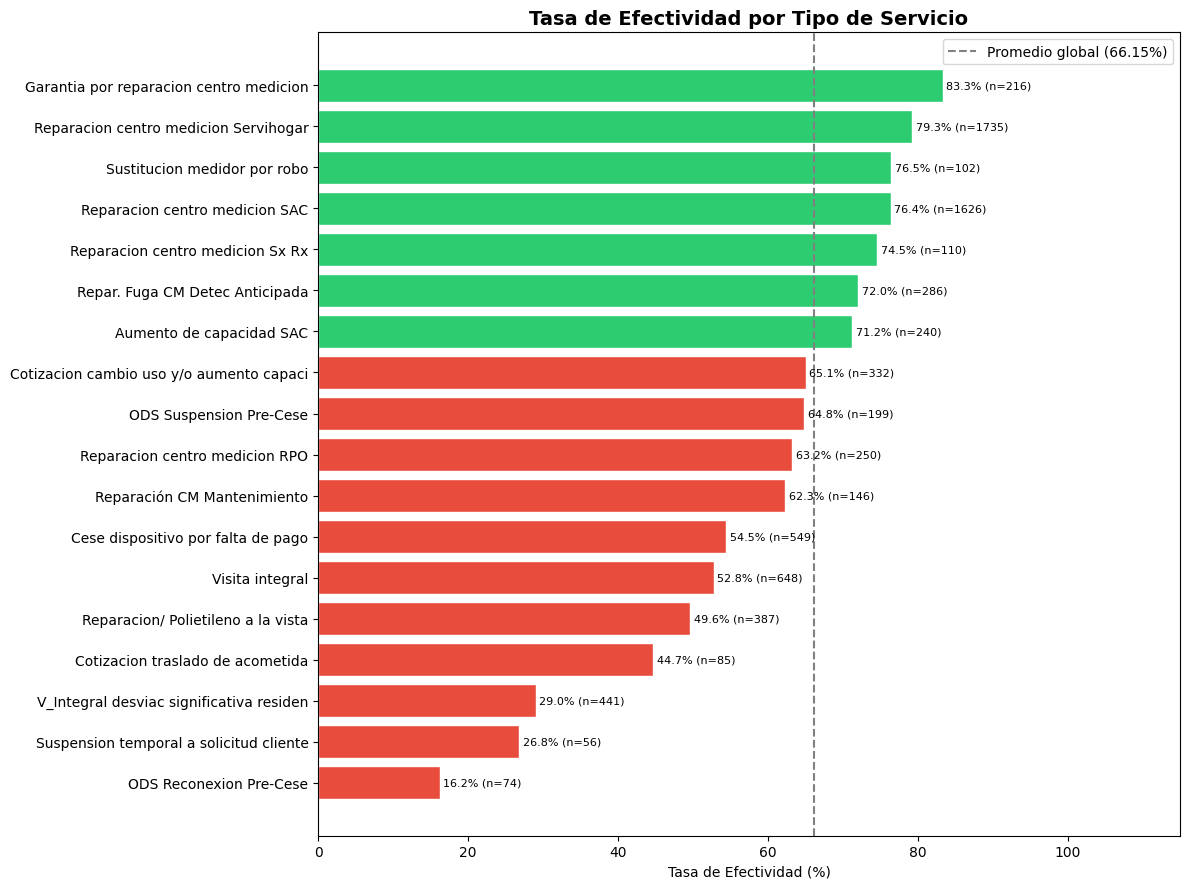

In [6]:
# Efectividad por tipo de servicio - top servicios por volumen
servicios = df.groupby('D_Prod._Serv')['Efectiva_num'].agg(['mean', 'count'])
servicios['mean'] = servicios['mean'] * 100
servicios = servicios[servicios['count'] >= 50].sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

colors_list = ['#E74C3C' if v < 66.15 else '#2ECC71' for v in servicios['mean']]

bars = ax.barh(servicios.index, servicios['mean'],
               color=colors_list, edgecolor='white')

for bar, val, cnt in zip(bars, servicios['mean'], servicios['count']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}% (n={cnt})', va='center', fontsize=8)

ax.axvline(x=66.15, color='gray', linestyle='--', label='Promedio global (66.15%)')
ax.set_title('Tasa de Efectividad por Tipo de Servicio', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Efectividad (%)')
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.savefig('efectividad_servicio.png', dpi=150)
plt.show()

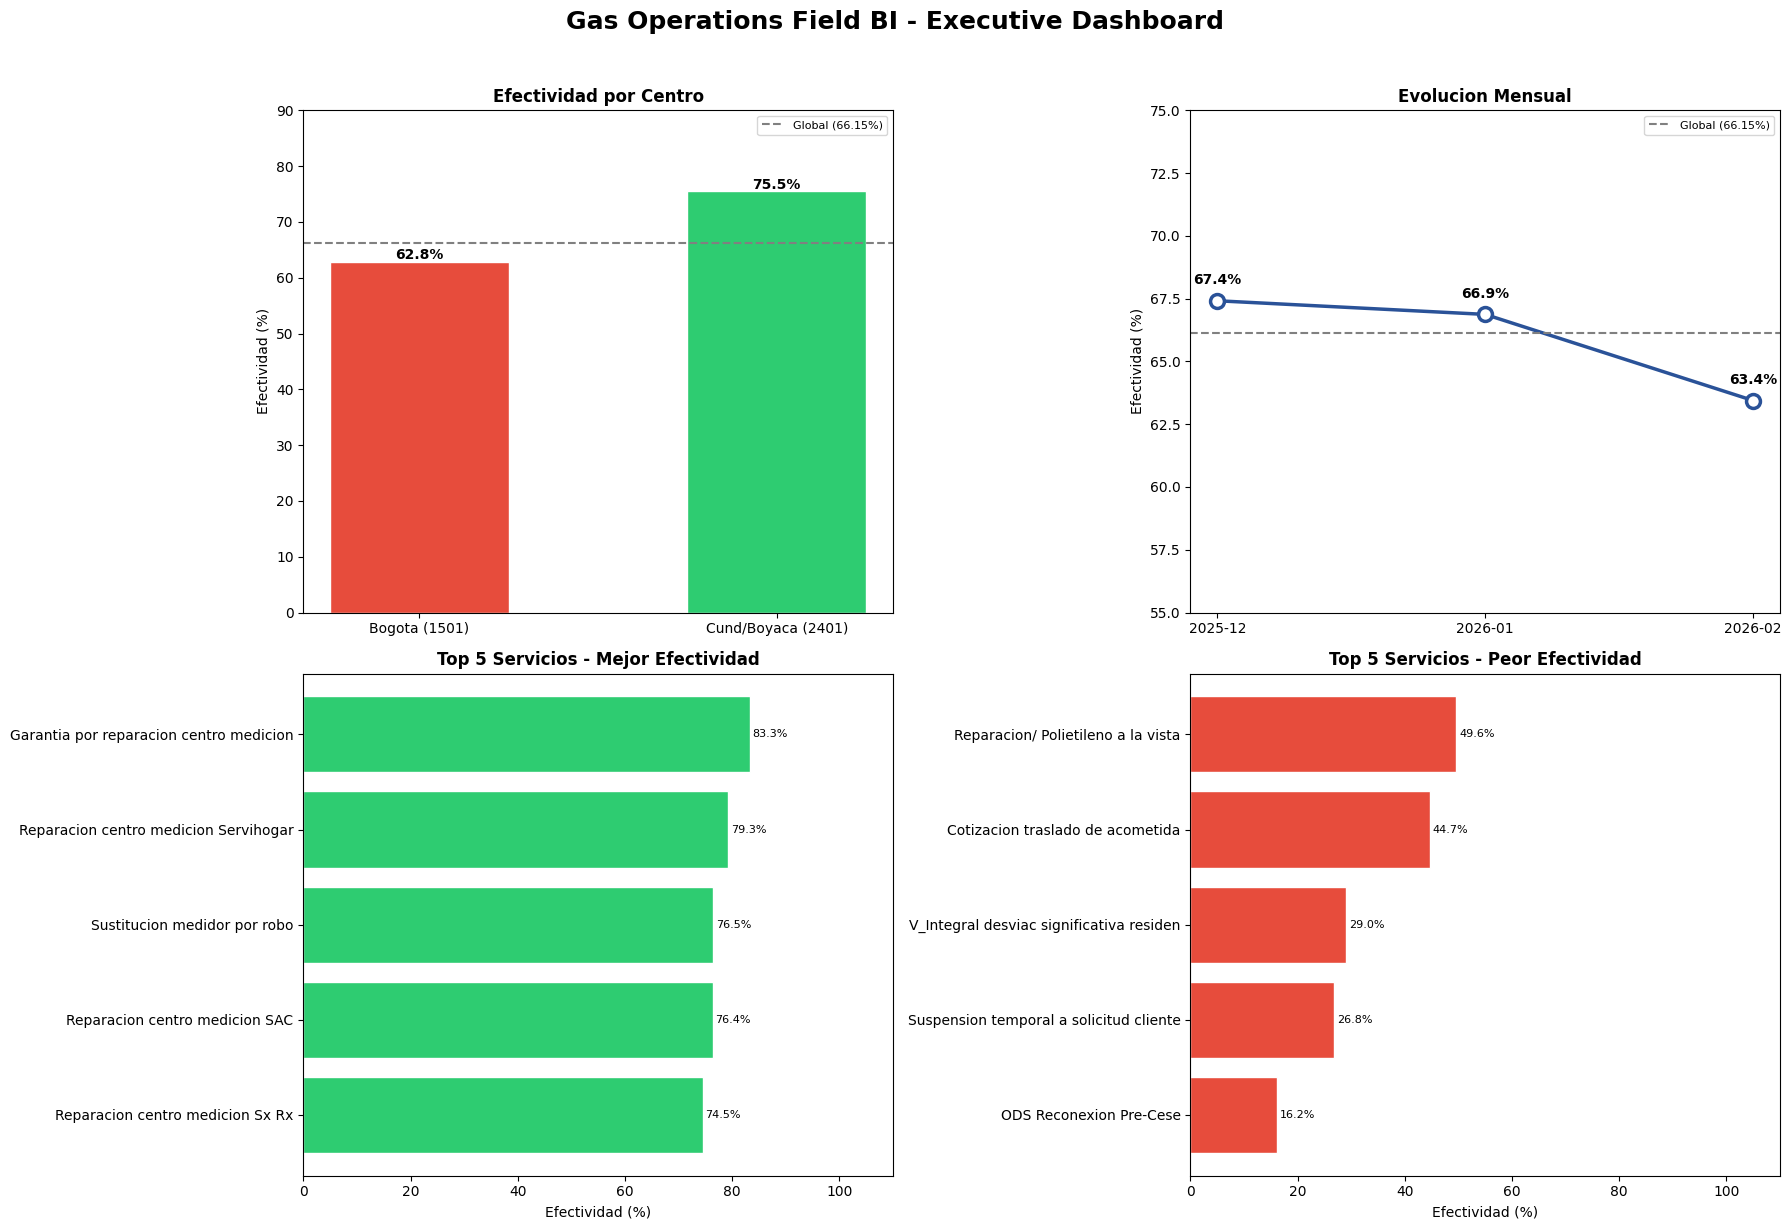

In [7]:
# Executive Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Gas Operations Field BI - Executive Dashboard',
             fontsize=18, fontweight='bold', y=1.02)

# Panel 1 - Efectividad por centro
efectividad_centro = df.groupby('Centro planificación')['Efectiva_num'].mean() * 100
bars1 = axes[0,0].bar(['Bogota (1501)', 'Cund/Boyaca (2401)'],
                       efectividad_centro.values,
                       color=['#E74C3C', '#2ECC71'], edgecolor='white', width=0.5)
for bar, val in zip(bars1, efectividad_centro.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', fontweight='bold')
axes[0,0].axhline(y=66.15, color='gray', linestyle='--', label='Global (66.15%)')
axes[0,0].set_title('Efectividad por Centro', fontweight='bold')
axes[0,0].set_ylabel('Efectividad (%)')
axes[0,0].set_ylim(0, 90)
axes[0,0].legend(fontsize=8)

# Panel 2 - Evolucion mensual
efectividad_mes = df.groupby('Mes')['Efectiva_num'].mean() * 100
axes[0,1].plot(efectividad_mes.index, efectividad_mes.values,
               marker='o', linewidth=2.5, markersize=10,
               color='#2A5298', markerfacecolor='white', markeredgewidth=2.5)
for x, y in zip(efectividad_mes.index, efectividad_mes.values):
    axes[0,1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                       xytext=(0, 12), ha='center', fontweight='bold', fontsize=10)
axes[0,1].axhline(y=66.15, color='gray', linestyle='--', label='Global (66.15%)')
axes[0,1].set_title('Evolucion Mensual', fontweight='bold')
axes[0,1].set_ylabel('Efectividad (%)')
axes[0,1].set_ylim(55, 75)
axes[0,1].legend(fontsize=8)

# Panel 3 - Top 5 servicios con mejor efectividad
top5_mejor = servicios.tail(5)
bars3 = axes[1,0].barh(top5_mejor.index, top5_mejor['mean'],
                        color='#2ECC71', edgecolor='white')
for bar, val in zip(bars3, top5_mejor['mean']):
    axes[1,0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=8)
axes[1,0].set_title('Top 5 Servicios - Mejor Efectividad', fontweight='bold')
axes[1,0].set_xlabel('Efectividad (%)')
axes[1,0].set_xlim(0, 110)

# Panel 4 - Top 5 servicios con peor efectividad
top5_peor = servicios.head(5)
bars4 = axes[1,1].barh(top5_peor.index, top5_peor['mean'],
                        color='#E74C3C', edgecolor='white')
for bar, val in zip(bars4, top5_peor['mean']):
    axes[1,1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=8)
axes[1,1].set_title('Top 5 Servicios - Peor Efectividad', fontweight='bold')
axes[1,1].set_xlabel('Efectividad (%)')
axes[1,1].set_xlim(0, 110)

plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 20.0 MB/s eta 0:00:00


In [9]:
from fpdf import FPDF

class GasOperationsReport(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 12)
        self.set_fill_color(30, 60, 114)
        self.set_text_color(255, 255, 255)
        self.cell(0, 12, 'Gas Operations Field BI - Executive Report',
                  fill=True, ln=True, align='C')
        self.ln(4)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(128, 128, 128)
        self.cell(0, 10, f'Page {self.page_no()} | Confidential - Natural Gas Distribution Company', align='C')

pdf = GasOperationsReport()
pdf.set_auto_page_break(auto=True, margin=15)

# ---- PAGE 1: OVERVIEW ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 20)
pdf.set_text_color(30, 60, 114)
pdf.ln(8)
pdf.cell(0, 12, 'Field Technician Operations Analysis', ln=True, align='C')
pdf.set_font('Helvetica', '', 11)
pdf.set_text_color(100, 100, 100)
pdf.cell(0, 8, 'Natural Gas Distribution Company in Colombia | Dec 2025 - Feb 2026',
         ln=True, align='C')
pdf.ln(10)

# KPIs
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 8, 'Key Performance Indicators', ln=True)
pdf.ln(3)

kpis = [
    ('Total Service Orders', '7,643'),
    ('Overall Effectiveness Rate', '66.15%'),
    ('Effective Orders', '5,056'),
    ('Non-Effective Orders', '2,587'),
    ('Planning Centers', '2 (Bogota / Cundinamarca-Boyaca)'),
    ('Field Technicians', '40'),
]

pdf.set_font('Helvetica', '', 11)
for label, value in kpis:
    pdf.set_fill_color(240, 244, 255)
    pdf.set_text_color(50, 50, 50)
    pdf.cell(100, 10, f'  {label}', fill=True, border=1)
    pdf.set_fill_color(30, 60, 114)
    pdf.set_text_color(255, 255, 255)
    pdf.cell(90, 10, f'  {value}', fill=True, border=1, ln=True)
    pdf.ln(1)

pdf.ln(8)

# Executive Summary
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 8, 'Executive Summary', ln=True)
pdf.set_font('Helvetica', '', 10)
pdf.set_text_color(50, 50, 50)
summary = """Analysis of 7,643 field service orders from a natural gas distribution company in Colombia
reveals a global effectiveness rate of 66.15%. The Cundinamarca/Boyaca center (2401) significantly
outperforms Bogota (1501) with 75.49% vs 62.83% effectiveness. A steady decline was observed from
December 2025 (67.4%) to February 2026 (63.4%), driven by operational process changes. Two key
findings distinguish systemic failures from operational ones: service orders triggered by consumption
deviations and uncoordinated scheduling by the distribution company account for a significant portion
of non-effectiveness, which cannot be attributed to field team performance."""
pdf.multi_cell(0, 6, summary)

# ---- PAGE 2: OPERATIONS PERSPECTIVE ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 10, 'Director of Operations Perspective', ln=True)
pdf.set_draw_color(30, 60, 114)
pdf.set_line_width(0.5)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(5)

findings_ops = [
    ('Finding 1 - Effectiveness by Planning Center',
     'Center 2401 (Cundinamarca/Boyaca) outperforms Center 1501 (Bogota) by 12.7 percentage points (75.49% vs 62.83%). Cultural and security factors in Bogota generate higher access refusal rates from users, which is a systemic issue beyond field team control.'),
    ('Finding 2 - Technician Performance',
     'Significant dispersion exists in Center 1501 (43% to 82%) vs Center 2401 (63% to 87%). High volume does not determine effectiveness - Milton Alarcon leads volume (560 orders) with 75.4% effectiveness, while lower-volume technicians show worse rates, suggesting individual management issues.'),
    ('Finding 3 - Service Type Performance',
     'Service orders triggered by consumption deviations (high-volume service type) show 52.8% effectiveness because users are not notified in advance. This is a systemic failure from the distribution company scheduling process, not a field team issue.'),
    ('Finding 4 - Monthly Trend',
     'Effectiveness declined steadily: Dec 2025 (67.4%) - Jan 2026 (66.9%) - Feb 2026 (63.4%). The 4-point drop over 3 months correlates with operational process changes introduced by the distribution company during this period.'),
]

for title, text in findings_ops:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.set_text_color(30, 60, 114)
    pdf.cell(0, 8, title, ln=True)
    pdf.set_font('Helvetica', '', 10)
    pdf.set_text_color(50, 50, 50)
    pdf.multi_cell(0, 6, text)
    pdf.ln(3)

pdf.ln(3)
pdf.set_font('Helvetica', 'B', 11)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 8, 'Operations Dashboard', ln=True)
pdf.image('executive_dashboard.png', x=10, w=190)

# ---- PAGE 3: GENERAL MANAGER PERSPECTIVE ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 10, 'General Manager Perspective', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(5)

findings_gm = [
    ('Finding 5 - Municipality Performance',
     'Bogota concentrates 2,018 non-effective orders (62.46% effectiveness) - the worst rate among high-volume municipalities. Rural municipalities consistently outperform Bogota (Duitama 89.3%, Facatativa 88.8%), confirming the territorial factor hypothesis related to user trust and access.'),
    ('Finding 6 - Market Segment Performance',
     'Industrial Non-Regulated leads with 83.0% effectiveness due to proper scheduling. Industrial Regulated shows the worst rate (42.1%) due to last-minute cancellations. Residential Nueva Edificacion (56.1%) presents the greatest opportunity for improvement among high-volume segments.'),
    ('Finding 7 - Service Type vs Systemic Issues',
     'Key distinction: non-effectiveness falls into two categories. Operational (manageable by field team): repair and maintenance services. Systemic (caused by distribution company processes): pre-suspension reconnections (16.2%), temporary suspensions (26.8%), and deviation visits (29.0%) where users are not notified.'),
    ('Finding 8 - Technician Ranking',
     'Rankings segmented by planning center reveal that Center 2401 is more homogeneous (24-point spread) while Center 1501 shows greater dispersion (38-point spread). Volume alone does not predict effectiveness - technicians with 300+ orders show rates from 43% to 75%, indicating individual management capacity differences.'),
]

for title, text in findings_gm:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.set_text_color(30, 60, 114)
    pdf.cell(0, 8, title, ln=True)
    pdf.set_font('Helvetica', '', 10)
    pdf.set_text_color(50, 50, 50)
    pdf.multi_cell(0, 6, text)
    pdf.ln(3)

# ---- PAGE 4: RECOMMENDATIONS ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 10, 'Strategic Recommendations', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(5)

recommendations = [
    ('IMMEDIATE', '1. Revert operational process changes introduced in Dec 2025 - Feb 2026 that caused the 4-point effectiveness decline. Identify specific changes and their impact per service type.'),
    ('IMMEDIATE', '2. Classify non-effectiveness by cause: systemic (distribution company) vs operational (field team). This separation is essential for accurate performance measurement.'),
    ('SHORT TERM', '3. Implement user pre-notification protocol for deviation visits. Users must be contacted 24-48 hours before the visit to reduce the 52.8% non-effectiveness rate in this service type.'),
    ('SHORT TERM', '4. Design individual improvement plans for technicians below 55% effectiveness in Center 1501. Focus on technicians with high volume and low effectiveness.'),
    ('MEDIUM TERM', '5. Develop a differentiated territorial strategy for Bogota: visible technician identification, same-day confirmation calls, and immediate rescheduling protocols to address user trust barriers.'),
]

for priority, text in recommendations:
    if priority == 'IMMEDIATE':
        pdf.set_fill_color(231, 76, 60)
    else:
        pdf.set_fill_color(52, 152, 219)

    pdf.set_text_color(255, 255, 255)
    pdf.set_font('Helvetica', 'B', 9)
    pdf.cell(40, 8, f'  {priority}', fill=True, border=1)
    pdf.set_fill_color(245, 245, 245)
    pdf.set_text_color(50, 50, 50)
    pdf.set_font('Helvetica', '', 9)
    pdf.multi_cell(150, 8, f'  {text}', fill=True, border=1)
    pdf.ln(2)

pdf.ln(8)
pdf.set_font('Helvetica', 'I', 9)
pdf.set_text_color(100, 100, 100)
pdf.cell(0, 6, 'Report generated automatically with Python | Project: gas-operations-field-bi',
         ln=True, align='C')

pdf.output('executive_report.pdf')
print("Report generated successfully: executive_report.pdf")

/tmp/ipykernel_7329/275322330.py:8: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 12, 'Gas Operations Field BI - Executive Report',
/tmp/ipykernel_7329/275322330.py:26: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 12, 'Field Technician Operations Analysis', ln=True, align='C')
/tmp/ipykernel_7329/275322330.py:29: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, 'Natural Gas Distribution Company in Colombia | Dec 2025 - Feb 2026',
/tmp/ipykernel_7329/275322330.py:36: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, 'Key Performance Indicators', ln=True)
/tmp/ipykernel_7329/275322330.py:55: DeprecationWarning: Th

Report generated successfully: executive_report.pdf


/tmp/ipykernel_7329/275322330.py:115: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, 'General Manager Perspective', ln=True)
/tmp/ipykernel_7329/275322330.py:133: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, title, ln=True)
/tmp/ipykernel_7329/275322330.py:143: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, 'Strategic Recommendations', ln=True)
/tmp/ipykernel_7329/275322330.py:173: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 6, 'Report generated automatically with Python | Project: gas-operations-field-bi',
